In [67]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [68]:
simulations_hegner = {}

for simulation_dir in Path("cluster_results/flow-otter-test").glob("temperature_*"):
    bandgaps = []
    temperature = float(simulation_dir.name.split("_")[-1])
    for snapshot_dir in simulation_dir.glob("2-DFT/config_*"):
        with open(snapshot_dir / "bandgap.log", "r") as f:
            line = f.readlines()[1]
            float_string = line.split(" ")[-1].strip()[:-1]
            bandgap = float(float_string)
            bandgaps.append(bandgap)
    simulations_hegner[temperature] = bandgaps

simulations_own = {}

for simulation_dir in Path("cluster_results/flow-otter-CuTaN2-5T").glob("temperature_*"):
    bandgaps = []
    temperature = float(simulation_dir.name.split("_")[-1])
    for snapshot_dir in simulation_dir.glob("2-DFT/config_*"):
        if not (snapshot_dir / "bandgap.log").exists():
            continue
        with open(snapshot_dir / "bandgap.log", "r") as f:
            line = f.readlines()[1]
            float_string = line.split(" ")[-1].strip()[:-1]
            bandgap = float(float_string)
            bandgaps.append(bandgap)
    simulations_own[temperature] = bandgaps

In [69]:
hegner_means = {k: np.mean(v) for k, v in simulations_hegner.items()}
own_means = {k: np.mean(v) for k, v in simulations_own.items()}
# sort own means by temperature
own_means = dict(sorted(own_means.items()))

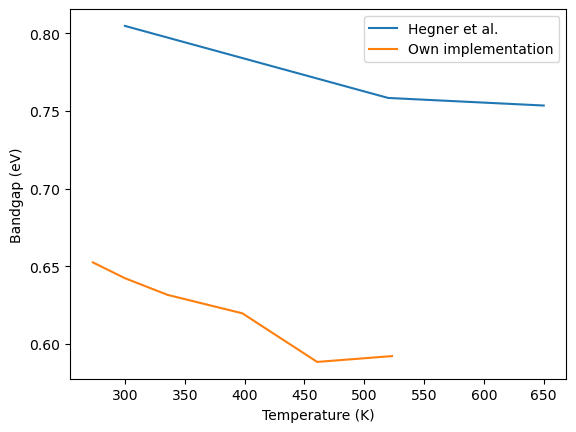

In [70]:
plt.plot(list(hegner_means.keys()), list(hegner_means.values()), label="Hegner et al.")
plt.plot(list(own_means.keys()), list(own_means.values()), label="Own implementation")
plt.xlabel("Temperature (K)")
plt.ylabel("Bandgap (eV)")
plt.legend()
plt.show()

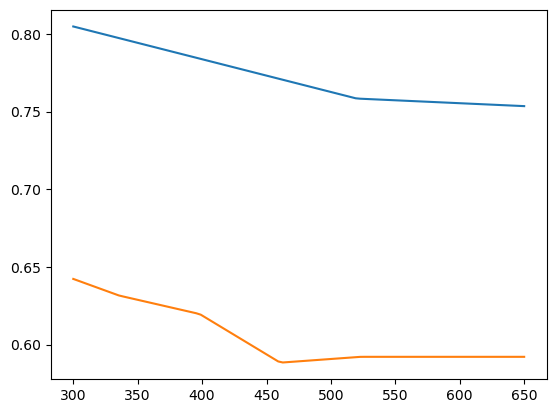

In [71]:
# find linear interpolations of the two means on a common temperature axis
common_temperatures = np.linspace(min(hegner_means.keys()), max(hegner_means.keys()), 100)
hegner_interpolated = np.interp(common_temperatures, list(hegner_means.keys()), list(hegner_means.values()))
own_interpolated = np.interp(common_temperatures, list(own_means.keys()), list(own_means.values()))

plt.plot(common_temperatures, hegner_interpolated, label="Hegner et al.")
plt.plot(common_temperatures, own_interpolated, label="Own implementation")

In [72]:
differences = hegner_interpolated - own_interpolated
print("Max difference:", np.max(np.abs(differences)))

Max difference: 0.18215712368952075


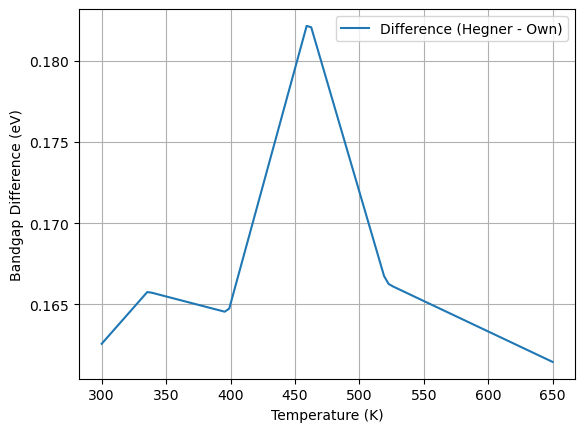

In [73]:
plt.plot(common_temperatures, hegner_interpolated - own_interpolated, label="Difference (Hegner - Own)")
plt.xlabel("Temperature (K)")
plt.ylabel("Bandgap Difference (eV)")
plt.legend()
plt.grid()
plt.show()

In [74]:
average_difference = np.mean(np.abs(differences))
print("Average difference:", average_difference)

Average difference: 0.16761843426343076


In [85]:
# fit varshni model to own means
def varshni(T, E0, B, T0):
    return E0 - B * T**2 / (T + T0)

popt, pcov = curve_fit(varshni, list(own_means.keys()), list(own_means.values()))

# print the fitted parameters
print("Fitted parameters:")
print("E0:", popt[0])
print("B:", popt[1])
print("T0:", popt[2])

Fitted parameters:
E0: 0.7210138273663199
B: 0.0002618340276220068
T0: 0.000715085901214144


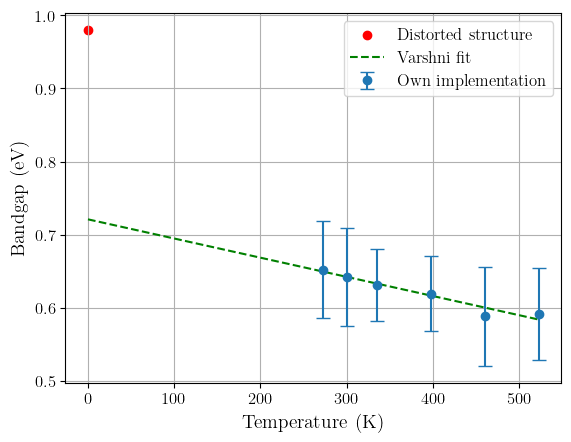

In [96]:
plt.rcParams.update(
    {
        "font.family": "serif",  # use serif/main font for text elements
        "text.usetex": True,  # use inline math for ticks
        "pgf.rcfonts": False,  # don't setup fonts from rc parameters
        "axes.labelsize": 14,  # axis labels
        "legend.fontsize": 12,  # legend
        "xtick.labelsize": 12,  # x tick labels
        "ytick.labelsize": 12,  # y tick labels
    }
)

# sort own means by temperature again after adding the new value
own_means = dict(sorted(own_means.items()))

plt.errorbar(
    list(own_means.keys()),
    list(own_means.values()),
    yerr=[np.std(v) for v in simulations_own.values()],
    fmt="o",
    label="Own implementation",
    capsize=5,
)
plt.scatter(0, 1.15 - 0.17, label="Distorted structure", color="red")

T = np.linspace(0, max(own_means.keys()), 100)

plt.plot(T, varshni(T, *popt), label="Varshni fit", linestyle="--", color="green")

plt.xlabel("Temperature (K)")
plt.ylabel("Bandgap (eV)")
plt.grid()
plt.legend()

plt.savefig("bandgap_vs_temperature_extrapolated.pdf", bbox_inches="tight")

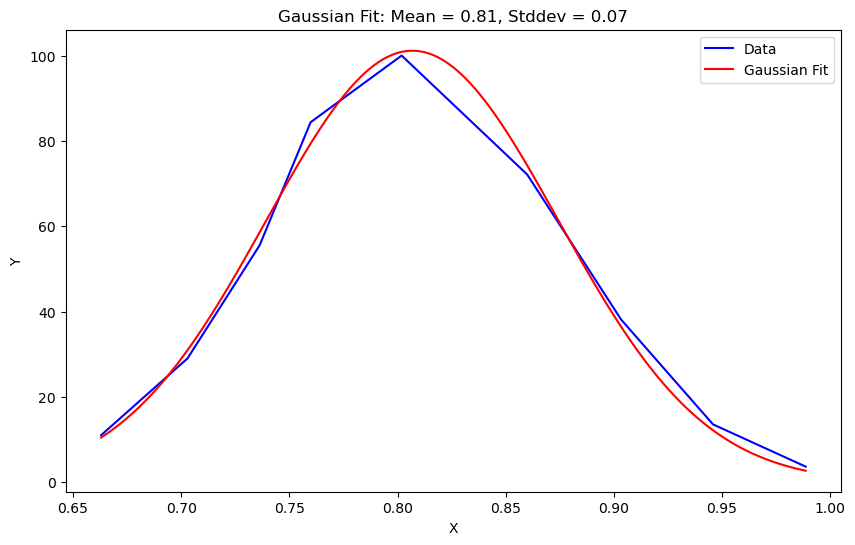

In [30]:
df = pd.read_csv("screen.csv")

X = df["x"].values
Y = df["Curve1"].values

# perform a gaussian fit to the data
from scipy.optimize import curve_fit

def gaussian(x, amplitude, mean, stddev):
    return amplitude * np.exp(-0.5 * ((x - mean) / stddev) ** 2)

p0 = [np.max(Y), X[np.argmax(Y)], np.std(X)]
popt, _ = curve_fit(gaussian, X, Y, p0=p0)

# plot data and the fit
plt.figure(figsize=(10, 6))
plt.plot(X, Y, label="Data", color="blue")
x_fit = np.linspace(np.min(X), np.max(X), 1000)
y_fit = gaussian(x_fit, *popt)
plt.plot(x_fit, y_fit, label="Gaussian Fit", color="red")

# print the mean and stddev of the fit
mean_fit = popt[1]
stddev_fit = popt[2]
plt.title(f"Gaussian Fit: Mean = {mean_fit:.2f}, Stddev = {stddev_fit:.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()